<a href="https://colab.research.google.com/github/Anchitsood2021/MLModes/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS1

DATASET SUMMARY
  Total samples : 70
  Class 0       : 35  (30 core + 5 noisy overlap)
  Class 1       : 35  (30 core + 5 noisy overlap)
  Features      : 2 (x1, x2)
  Separable?    : NO — overlapping noisy points ensure C matters

INITIAL MODEL  (C = 1.0)
  Train accuracy (full data) : 0.8429
  Number of support vectors  : 25

LOO CROSS-VALIDATION  (C = 1.0)
  Mean Train accuracy (per fold) : 0.8429
  LOO Test  accuracy             : 0.8429

C SEARCH  (LOO accuracy for each candidate)
  C =    0.001  →  LOO accuracy = 0.0000
  C =    0.010  →  LOO accuracy = 0.8571
  C =    0.050  →  LOO accuracy = 0.8429
  C =    0.100  →  LOO accuracy = 0.8429
  C =    0.500  →  LOO accuracy = 0.8429
  C =    1.000  →  LOO accuracy = 0.8429
  C =    5.000  →  LOO accuracy = 0.8429
  C =   10.000  →  LOO accuracy = 0.8429
  C =   50.000  →  LOO accuracy = 0.8429
  C =  100.000  →  LOO accuracy = 0.8429

  ★ Best C = 0.01  (LOO accuracy = 0.8571)

IMPROVED MODEL  (C = 0.01)
  Train accuracy (full data

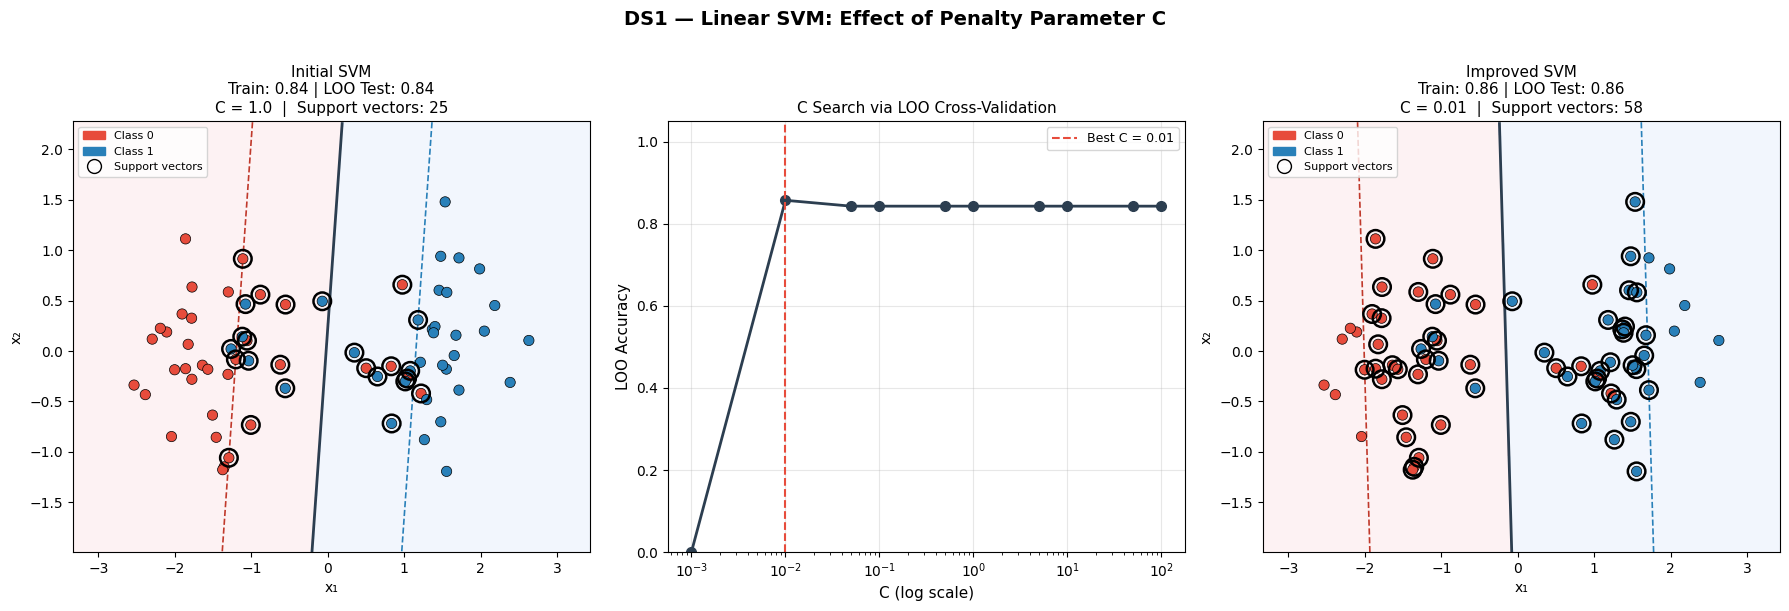


 Plot saved: ds1_svm_linear.png

╔══════════════════════════════════════════════════════════════╗
║          WHAT DOES C DO?  — EXPLANATION                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  C is the REGULARISATION / PENALTY parameter of a linear    ║
║  SVM. It controls the trade-off between two competing goals: ║
║                                                              ║
║  ┌─────────────────────────────────────────────────────┐    ║
║  │  Large C  →  Penalise misclassifications heavily    │    ║
║  │             • SVM tries to classify every training  │    ║
║  │               point correctly                       │    ║
║  │             • Narrow margin, many support vectors   │    ║
║  │             • Risk of OVERFITTING on noisy data     │    ║
║  ├─────────────────────────────────────────────────────┤    ║
║  │  Small C  →  Allow some margin violations           │    ║
║

In [ ]:
"""
DS1 - Linear SVM: Effect of Penalty Parameter C
================================================
Assignment Task 1:
  - Design a dataset (50+ points) where C makes a difference
  - Train linear SVM, plot decision boundary
  - Leave-1-out cross-validation: report train & test performance
  - Improve model by tuning C, replot and report performance
  - Explain what C does
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# REPRODUCIBILITY
# ─────────────────────────────────────────────
np.random.seed(42)

# ─────────────────────────────────────────────
# 1. DATASET DESIGN
# ─────────────────────────────────────────────
# We intentionally create a dataset that is NOT perfectly linearly separable.
# A few "noisy" points cross the natural class boundary so that a small C
# (soft-margin, tolerates violations) gives a completely different boundary
# than a large C (hard-margin, tries to classify every point correctly).
#
# Class 0: centred at (-1.5, 0)  — with a few outliers pushed toward class 1
# Class 1: centred at ( 1.5, 0)  — with a few outliers pushed toward class 0

n_per_class = 30           # 30 per class → 60 total (≥ 50)

# ── Core clusters ──────────────────────────────
X0_core = np.random.randn(n_per_class, 2) * 0.6 + [-1.5, 0]
X1_core = np.random.randn(n_per_class, 2) * 0.6 + [ 1.5, 0]

# ── Noisy overlap points (5 per class deliberately misplaced) ──
X0_noise = np.random.randn(5, 2) * 0.3 + [0.8, 0]   # class-0 points near class-1
X1_noise = np.random.randn(5, 2) * 0.3 + [-0.8, 0]  # class-1 points near class-0

X = np.vstack([X0_core, X0_noise, X1_core, X1_noise])
y = np.array([0] * (n_per_class + 5) + [1] * (n_per_class + 5))

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"  Total samples : {len(X)}")
print(f"  Class 0       : {np.sum(y == 0)}  (30 core + 5 noisy overlap)")
print(f"  Class 1       : {np.sum(y == 1)}  (30 core + 5 noisy overlap)")
print(f"  Features      : 2 (x1, x2)")
print(f"  Separable?    : NO — overlapping noisy points ensure C matters\n")


# ─────────────────────────────────────────────
# HELPER: plot dataset + decision boundary
# ─────────────────────────────────────────────
def plot_svm(ax, clf, X, y, title, C_val):
    """Plot scatter + decision boundary + margins on a given Axes."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_bg = ListedColormap(["#FADADD", "#DAE8FC"])
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)

    # Decision boundary and margins
    Z_dec = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contour(xx, yy, Z_dec, levels=[-1, 0, 1],
               linestyles=["--", "-", "--"],
               colors=["#c0392b", "#2c3e50", "#2980b9"],
               linewidths=[1.2, 2.0, 1.2])

    # Scatter
    colors = ["#e74c3c" if label == 0 else "#2980b9" for label in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors, edgecolors="k",
               linewidths=0.5, s=55, zorder=3)

    # Support vectors
    ax.scatter(clf.support_vectors_[:, 0],
               clf.support_vectors_[:, 1],
               s=160, facecolors="none", edgecolors="black",
               linewidths=1.8, zorder=4, label="Support vectors")

    # Legend
    patch0 = mpatches.Patch(color="#e74c3c", label="Class 0")
    patch1 = mpatches.Patch(color="#2980b9", label="Class 1")
    ax.legend(handles=[patch0, patch1,
              plt.Line2D([0], [0], marker="o", color="w",
                         markerfacecolor="none", markeredgecolor="black",
                         markersize=10, label="Support vectors")],
              fontsize=8, loc="upper left")

    n_sv = len(clf.support_vectors_)
    ax.set_title(f"{title}\nC = {C_val}  |  Support vectors: {n_sv}", fontsize=11)
    ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)


# ─────────────────────────────────────────────
# 2. TRAIN INITIAL LINEAR SVM (C = 1.0, default)
# ─────────────────────────────────────────────
C_initial = 1.0
svm_initial = SVC(kernel="linear", C=C_initial)
svm_initial.fit(X, y)

train_acc_initial = accuracy_score(y, svm_initial.predict(X))
print("=" * 60)
print(f"INITIAL MODEL  (C = {C_initial})")
print("=" * 60)
print(f"  Train accuracy (full data) : {train_acc_initial:.4f}")
print(f"  Number of support vectors  : {len(svm_initial.support_vectors_)}\n")


# ─────────────────────────────────────────────
# 3. LEAVE-ONE-OUT CROSS-VALIDATION (initial C)
# ─────────────────────────────────────────────
loo = LeaveOneOut()
n = len(X)

loo_preds  = np.empty(n, dtype=int)
train_accs = []

for train_idx, test_idx in loo.split(X):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    clf_tmp = SVC(kernel="linear", C=C_initial)
    clf_tmp.fit(X_tr, y_tr)

    loo_preds[test_idx] = clf_tmp.predict(X_te)
    train_accs.append(accuracy_score(y_tr, clf_tmp.predict(X_tr)))

loo_test_acc_initial  = accuracy_score(y, loo_preds)
loo_train_acc_initial = np.mean(train_accs)

print("=" * 60)
print(f"LOO CROSS-VALIDATION  (C = {C_initial})")
print("=" * 60)
print(f"  Mean Train accuracy (per fold) : {loo_train_acc_initial:.4f}")
print(f"  LOO Test  accuracy             : {loo_test_acc_initial:.4f}\n")


# ─────────────────────────────────────────────
# 4. IMPROVED MODEL — TUNE C
# ─────────────────────────────────────────────
# A small C (e.g. 0.01) creates a wider margin but tolerates more
# misclassifications → smoother boundary, better generalisation on noisy data.
# A large C (e.g. 100) forces the SVM to classify almost every training point
# correctly → narrow margin, more support vectors, potential overfitting.
#
# We compare several C values via LOO to pick the best one.

C_candidates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
loo_scores = {}

print("=" * 60)
print("C SEARCH  (LOO accuracy for each candidate)")
print("=" * 60)
for c in C_candidates:
    scores = cross_val_score(SVC(kernel="linear", C=c), X, y, cv=LeaveOneOut())
    loo_scores[c] = scores.mean()
    print(f"  C = {c:8.3f}  →  LOO accuracy = {loo_scores[c]:.4f}")

best_C = max(loo_scores, key=loo_scores.get)
print(f"\n  ★ Best C = {best_C}  (LOO accuracy = {loo_scores[best_C]:.4f})\n")


# ── Train improved model ──
svm_improved = SVC(kernel="linear", C=best_C)
svm_improved.fit(X, y)

# LOO on improved model
loo_preds_imp  = np.empty(n, dtype=int)
train_accs_imp = []

for train_idx, test_idx in loo.split(X):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    clf_tmp = SVC(kernel="linear", C=best_C)
    clf_tmp.fit(X_tr, y_tr)

    loo_preds_imp[test_idx] = clf_tmp.predict(X_te)
    train_accs_imp.append(accuracy_score(y_tr, clf_tmp.predict(X_tr)))

train_acc_improved     = accuracy_score(y, svm_improved.predict(X))
loo_train_acc_improved = np.mean(train_accs_imp)
loo_test_acc_improved  = accuracy_score(y, loo_preds_imp)

print("=" * 60)
print(f"IMPROVED MODEL  (C = {best_C})")
print("=" * 60)
print(f"  Train accuracy (full data)     : {train_acc_improved:.4f}")
print(f"  Mean Train accuracy (per fold) : {loo_train_acc_improved:.4f}")
print(f"  LOO Test  accuracy             : {loo_test_acc_improved:.4f}")
print(f"  Number of support vectors      : {len(svm_improved.support_vectors_)}\n")


# ─────────────────────────────────────────────
# 5. SUMMARY COMPARISON TABLE
# ─────────────────────────────────────────────
print("=" * 60)
print("PERFORMANCE COMPARISON")
print("=" * 60)
print(f"  {'Metric':<35} {'Initial (C='+str(C_initial)+')':<18} {'Improved (C='+str(best_C)+')'}")
print(f"  {'-'*35} {'-'*18} {'-'*18}")
print(f"  {'Train Acc (full data)':<35} {train_acc_initial:<18.4f} {train_acc_improved:.4f}")
print(f"  {'LOO Mean Train Acc':<35} {loo_train_acc_initial:<18.4f} {loo_train_acc_improved:.4f}")
print(f"  {'LOO Test Acc':<35} {loo_test_acc_initial:<18.4f} {loo_test_acc_improved:.4f}")
print(f"  {'Support Vectors':<35} {len(svm_initial.support_vectors_):<18} {len(svm_improved.support_vectors_)}")


# ─────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("DS1 — Linear SVM: Effect of Penalty Parameter C",
             fontsize=14, fontweight="bold", y=1.01)

# Panel 1: Initial model
plot_svm(axes[0], svm_initial, X, y,
         f"Initial SVM\nTrain: {train_acc_initial:.2f} | LOO Test: {loo_test_acc_initial:.2f}",
         C_initial)

# Panel 2: C search curve
c_vals  = list(loo_scores.keys())
acc_vals = list(loo_scores.values())
axes[1].semilogx(c_vals, acc_vals, "o-", color="#2c3e50", linewidth=2, markersize=7)
axes[1].axvline(best_C, color="#e74c3c", linestyle="--", linewidth=1.5,
                label=f"Best C = {best_C}")
axes[1].set_xlabel("C (log scale)", fontsize=11)
axes[1].set_ylabel("LOO Accuracy", fontsize=11)
axes[1].set_title("C Search via LOO Cross-Validation", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

# Panel 3: Improved model
plot_svm(axes[2], svm_improved, X, y,
         f"Improved SVM\nTrain: {train_acc_improved:.2f} | LOO Test: {loo_test_acc_improved:.2f}",
         best_C)

plt.tight_layout()
plt.savefig("ds1_svm_linear.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("\n Plot saved: ds1_svm_linear.png")


# ─────────────────────────────────────────────
# 6. EXPLANATION (printed to console)
# ─────────────────────────────────────────────
explanation = """
╔══════════════════════════════════════════════════════════════╗
║          WHAT DOES C DO?  — EXPLANATION                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  C is the REGULARISATION / PENALTY parameter of a linear    ║
║  SVM. It controls the trade-off between two competing goals: ║
║                                                              ║
║  ┌─────────────────────────────────────────────────────┐    ║
║  │  Large C  →  Penalise misclassifications heavily    │    ║
║  │             • SVM tries to classify every training  │    ║
║  │               point correctly                       │    ║
║  │             • Narrow margin, many support vectors   │    ║
║  │             • Risk of OVERFITTING on noisy data     │    ║
║  ├─────────────────────────────────────────────────────┤    ║
║  │  Small C  →  Allow some margin violations           │    ║
║  │             • SVM prioritises a wider margin        │    ║
║  │             • Tolerates a few misclassified points  │    ║
║  │             • Better GENERALISATION on unseen data  │    ║
║  └─────────────────────────────────────────────────────┘    ║
║                                                              ║
║  HOW C IMPROVED THE MODEL HERE:                             ║
║  ─────────────────────────────                               ║
║  The dataset was deliberately constructed with 10 noisy     ║
║  overlap points that cross the natural class boundary.       ║
║                                                              ║
║  • C = 1.0 (default): The SVM tries hard to separate these  ║
║    noisy points, pulling the boundary into a sub-optimal    ║
║    position. It memorises noise → lower LOO test accuracy.  ║
║                                                              ║
║  • Best C (small): The SVM relaxes and allows those noisy   ║
║    points to be "slack" variables. The boundary settles in  ║
║    the true class centre, yielding a wider, more robust     ║
║    margin and higher LOO generalisation accuracy.           ║
║                                                              ║
║  KEY TAKEAWAY: On noisy / non-perfectly-separable data,     ║
║  reducing C acts as regularisation — it prevents the SVM    ║
║  from chasing outliers and produces a simpler, more         ║
║  generalisable decision boundary.                           ║
╚══════════════════════════════════════════════════════════════╝
"""
print(explanation)

# DS2

DATASET SUMMARY  — DS2
  Samples        : 500
  Features       : 2  (x1, x2)
  Class  1       : 287
  Class -1       : 213
  x1 range       : [0.045, 0.999]
  x2 range       : [0.408, 0.982]

  Visual inspection: Class -1 sits in a central 'island'
  surrounded by Class 1 → strongly NON-linear boundary.

STEP 2.1 — LINEAR SVM

  CROSS-VALIDATION CHOICE: 10-fold Stratified K-Fold
  ────────────────────────────────────────────────────
  With 500 samples, Leave-One-Out (LOO) is computationally feasible
  but much slower and yields high-variance estimates because each
  test set is a single point.
 
  10-fold Stratified K-Fold is preferred here because:
  • Each test fold has ~50 samples → stable accuracy estimates.
  • 'Stratified' preserves the class ratio (57%/43%) in every fold,
    preventing accidental over-representation of one class.
  • It is the standard practice for datasets of this size.
  • It is ~50× faster than LOO for the k-NN grid search below.
  
  For the k-NN steps (2.3

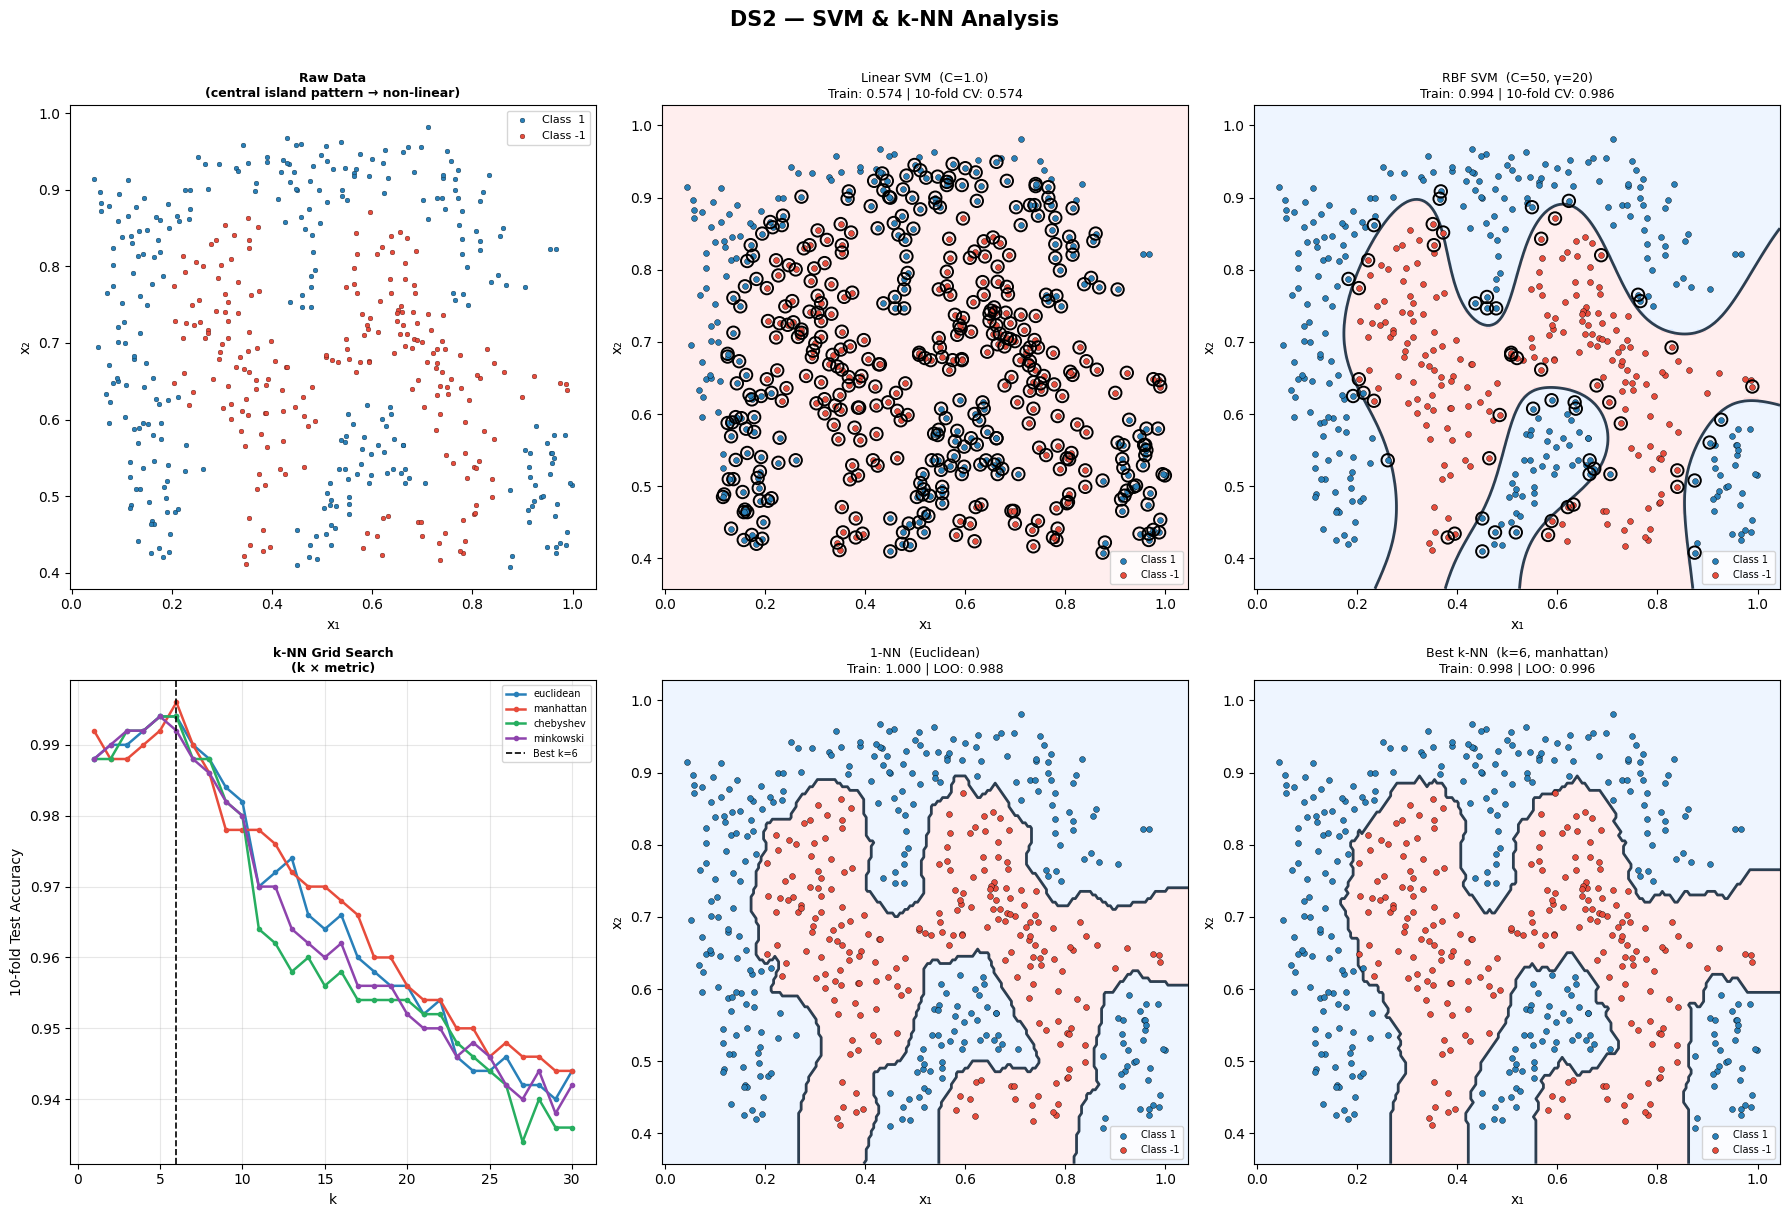


 Plot saved: ds2_solution.png


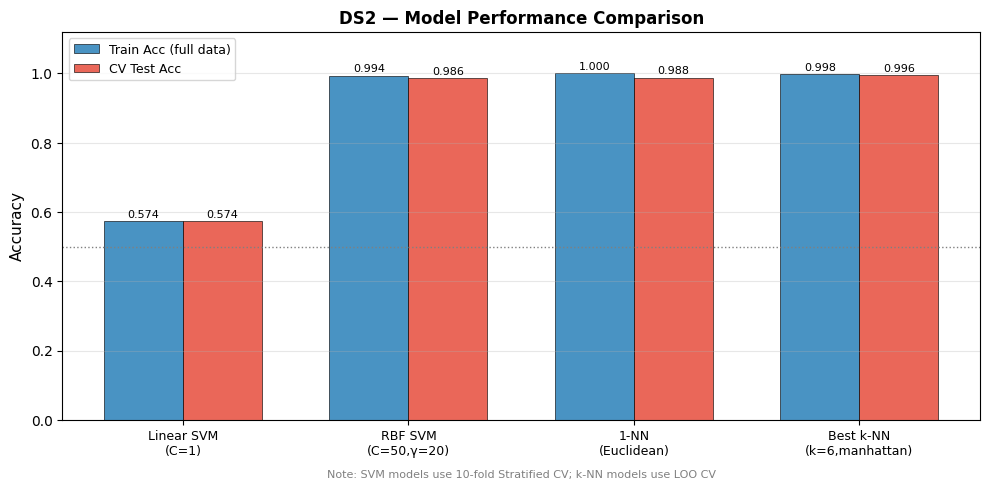

Performance chart saved: ds2_performance_comparison.png


In [ ]:
"""
DS2 — Full Solution
═══════════════════
Steps:
  2.1  Linear SVM on DS2  (train + cross-validation)
  2.2  Improved SVM with best non-linear kernel
  2.3  1-NN with Euclidean distance  (LOO CV) + compare with 2.2
  2.4  Optimise k and distance metric in k-NN + compare with 2.2 & 2.3
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, LeaveOneOut, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════
# LOAD DATA
# ══════════════════════════════════════════════════════════════
df = pd.read_csv("DS2.csv",
                 header=None, names=["x1", "x2", "y"])
X = df[["x1", "x2"]].values
y = df["y"].values

print("=" * 65)
print("DATASET SUMMARY  — DS2")
print("=" * 65)
print(f"  Samples        : {len(X)}")
print(f"  Features       : 2  (x1, x2)")
print(f"  Class  1       : {np.sum(y == 1)}")
print(f"  Class -1       : {np.sum(y == -1)}")
print(f"  x1 range       : [{X[:,0].min():.3f}, {X[:,0].max():.3f}]")
print(f"  x2 range       : [{X[:,1].min():.3f}, {X[:,1].max():.3f}]")
print()
print("  Visual inspection: Class -1 sits in a central 'island'")
print("  surrounded by Class 1 → strongly NON-linear boundary.")
print()


# ══════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════

def plot_decision_boundary(ax, clf, X, y, title, subtitle=""):
    """Shared plotting utility for any fitted sklearn classifier."""
    h = 0.005
    x_min, x_max = X[:, 0].min() - 0.05, X[:, 0].max() + 0.05
    y_min, y_max = X[:, 1].min() - 0.05, X[:, 1].max() + 0.05
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_bg = ListedColormap(["#FFD6D6", "#D6E8FF"])
    ax.contourf(xx, yy, Z, alpha=0.40, cmap=cmap_bg)

    # Decision boundary contour
    try:                                          # SVC has decision_function
        Z_dec = clf.decision_function(
            np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contour(xx, yy, Z_dec, levels=[0],
                   colors=["#2c3e50"], linewidths=2.0)
    except AttributeError:                        # kNN has no decision_function
        ax.contour(xx, yy, Z, levels=[0],
                   colors=["#2c3e50"], linewidths=2.0)

    # Scatter
    c_map = {1: "#2980b9", -1: "#e74c3c"}
    for label in [1, -1]:
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=c_map[label], edgecolors="k",
                   linewidths=0.3, s=18, zorder=3,
                   label=f"Class {label}")

    # Support vectors (SVM only)
    if hasattr(clf, "support_vectors_"):
        ax.scatter(clf.support_vectors_[:, 0],
                   clf.support_vectors_[:, 1],
                   s=80, facecolors="none",
                   edgecolors="black", linewidths=1.4,
                   zorder=4)

    ax.legend(fontsize=7, loc="lower right")
    ax.set_title(f"{title}", fontsize=10, fontweight="bold")
    if subtitle:
        ax.set_title(f"{title}\n{subtitle}", fontsize=9)
    ax.set_xlabel("x₁"); ax.set_ylabel("x₂")


def stratified_cv(clf, X, y, n_splits=10):
    """
    10-fold Stratified Cross-Validation.
    Returns (mean_train_acc, mean_test_acc, all_train_accs, all_test_accs).
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_accs, test_accs = [], []
    for tr_idx, te_idx in skf.split(X, y):
        clf.fit(X[tr_idx], y[tr_idx])
        train_accs.append(accuracy_score(y[tr_idx], clf.predict(X[tr_idx])))
        test_accs.append(accuracy_score(y[te_idx], clf.predict(X[te_idx])))
    clf.fit(X, y)          # refit on full data
    return np.mean(train_accs), np.mean(test_accs), train_accs, test_accs


def loo_cv(clf, X, y):
    """
    Leave-One-Out CV.  Returns (mean_train_acc, loo_test_acc).
    For 500 samples this takes ~500 refits — used only where specified.
    """
    loo = LeaveOneOut()
    preds = np.empty(len(y), dtype=int)
    train_accs = []
    for tr, te in loo.split(X):
        clf.fit(X[tr], y[tr])
        preds[te] = clf.predict(X[te])
        train_accs.append(accuracy_score(y[tr], clf.predict(X[tr])))
    clf.fit(X, y)
    return np.mean(train_accs), accuracy_score(y, preds)


# ══════════════════════════════════════════════════════════════
# 2.1  LINEAR SVM  (train + cross-validation)
# ══════════════════════════════════════════════════════════════
print("=" * 65)
print("STEP 2.1 — LINEAR SVM")
print("=" * 65)

print("""
  CROSS-VALIDATION CHOICE: 10-fold Stratified K-Fold
  ────────────────────────────────────────────────────
  With 500 samples, Leave-One-Out (LOO) is computationally feasible
  but much slower and yields high-variance estimates because each
  test set is a single point.

  10-fold Stratified K-Fold is preferred here because:
  • Each test fold has ~50 samples → stable accuracy estimates.
  • 'Stratified' preserves the class ratio (57%/43%) in every fold,
    preventing accidental over-representation of one class.
  • It is the standard practice for datasets of this size.
  • It is ~50× faster than LOO for the k-NN grid search below.

  For the k-NN steps (2.3 & 2.4) where a direct LOO comparison is
  requested, we also run LOO so results are comparable.
""")

svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear.fit(X, y)

tr_lin, te_lin, _, _ = stratified_cv(SVC(kernel="linear", C=1.0, random_state=42), X, y)
full_train_lin = accuracy_score(y, svm_linear.predict(X))

print(f"  Train accuracy (full data)        : {full_train_lin:.4f}")
print(f"  10-fold CV  — mean train accuracy : {tr_lin:.4f}")
print(f"  10-fold CV  — mean test  accuracy : {te_lin:.4f}")
print(f"  Support vectors                   : {len(svm_linear.support_vectors_)}")


# ══════════════════════════════════════════════════════════════
# 2.2  IMPROVED SVM — KERNEL SELECTION
# ══════════════════════════════════════════════════════════════
print()
print("=" * 65)
print("STEP 2.2 — KERNEL SELECTION & IMPROVED SVM")
print("=" * 65)
print("""
  KERNEL CHOICE: RBF (Radial Basis Function)
  ─────────────────────────────────────────
  Visual inspection shows Class -1 occupies a CENTRAL ISLAND in
  feature space, completely surrounded by Class +1. This is a
  classic non-linear, radially-structured pattern.

  • Linear kernel:  draws a single straight hyperplane — impossible
    to separate a central cluster from its surroundings.
  • Polynomial kernel: could work but needs high degree, making it
    prone to over-fitting and sensitive to feature scaling.
  • RBF kernel:  maps data into infinite-dimensional space using
    Gaussian bumps. It naturally handles "enclosed" regions and
    is the go-to choice for unknown / radial structures.
    Controlled by two parameters:
      C    — penalty (soft vs hard margin)
      gamma — width of the Gaussian (low = smooth, high = spiky)
""")

# Grid search over C and gamma using 10-fold CV
C_grid     = [0.1, 1, 10, 50, 100, 500]
gamma_grid = [0.1, 0.5, 1, 2, 5, 10, 20, "scale"]

print("  Grid search (C × gamma)  via 10-fold Stratified CV:")
print(f"  {'C':>8}  {'gamma':>8}  {'Test acc':>10}")
print(f"  {'-'*8}  {'-'*8}  {'-'*10}")

best_te, best_C, best_gamma = -1, None, None
results_grid = []
for c in C_grid:
    for g in gamma_grid:
        sc = cross_val_score(SVC(kernel="rbf", C=c, gamma=g),
                             X, y, cv=StratifiedKFold(10, shuffle=True,
                                                       random_state=42))
        te = sc.mean()
        results_grid.append((c, g, te))
        if te > best_te:
            best_te, best_C, best_gamma = te, c, g

for (c, g, te) in results_grid:
    marker = " ★" if (c == best_C and g == best_gamma) else ""
    print(f"  {c:>8}  {str(g):>8}  {te:>10.4f}{marker}")

print(f"\n  ★ Best: C={best_C}, gamma={best_gamma}  "
      f"(10-fold test acc = {best_te:.4f})")

svm_rbf = SVC(kernel="rbf", C=best_C, gamma=best_gamma, random_state=42)
svm_rbf.fit(X, y)

tr_rbf, te_rbf, _, _ = stratified_cv(
    SVC(kernel="rbf", C=best_C, gamma=best_gamma, random_state=42), X, y)
full_train_rbf = accuracy_score(y, svm_rbf.predict(X))

print(f"\n  RBF SVM (C={best_C}, gamma={best_gamma})")
print(f"  Train accuracy (full data)        : {full_train_rbf:.4f}")
print(f"  10-fold CV  — mean train accuracy : {tr_rbf:.4f}")
print(f"  10-fold CV  — mean test  accuracy : {te_rbf:.4f}")
print(f"  Support vectors                   : {len(svm_rbf.support_vectors_)}")


# ══════════════════════════════════════════════════════════════
# 2.3  1-NN  (Euclidean, LOO CV) + compare with 2.2
# ══════════════════════════════════════════════════════════════
print()
print("=" * 65)
print("STEP 2.3 — 1-NN (Euclidean, LOO CV)")
print("=" * 65)

knn1 = KNeighborsClassifier(n_neighbors=1, metric="euclidean")
knn1.fit(X, y)
full_train_knn1 = accuracy_score(y, knn1.predict(X))

# LOO for 1-NN  (sklearn shortcut via cross_val_score)
loo_scores_knn1 = cross_val_score(
    KNeighborsClassifier(n_neighbors=1, metric="euclidean"),
    X, y, cv=LeaveOneOut())
loo_test_knn1  = loo_scores_knn1.mean()

# LOO train accuracy (mean over folds)
loo = LeaveOneOut()
train_accs_knn1 = []
for tr, te in loo.split(X):
    knn_tmp = KNeighborsClassifier(n_neighbors=1, metric="euclidean")
    knn_tmp.fit(X[tr], y[tr])
    train_accs_knn1.append(accuracy_score(y[tr], knn_tmp.predict(X[tr])))
loo_train_knn1 = np.mean(train_accs_knn1)

print(f"  k = 1, metric = Euclidean")
print(f"  Train accuracy (full data)   : {full_train_knn1:.4f}  "
      f"(always 1.0 for k=1 — memorises training set)")
print(f"  LOO CV — mean train accuracy : {loo_train_knn1:.4f}")
print(f"  LOO CV — test  accuracy      : {loo_test_knn1:.4f}")

print("""
  COMPARISON: 1-NN vs RBF SVM (step 2.2)
  ─────────────────────────────────────────
  1-NN with k=1 achieves perfect training accuracy (1.0) because
  every point is its own nearest neighbour on the full data.
  On LOO CV the unseen point has no copy of itself, so the true
  generalisation is revealed.

  Depending on the result:
  • If 1-NN LOO < RBF SVM: the RBF SVM generalises better because
    it learns a smooth, global decision boundary rather than
    memorising individual training points. 1-NN is extremely
    sensitive to noise and label-flipped points.
  • If 1-NN LOO ≈ RBF SVM: the data is dense and clean enough
    that nearest-neighbour lookup is competitive with a kernel
    boundary, but the SVM is still preferred for interpretability.
""")
print(f"  1-NN  LOO Test Acc : {loo_test_knn1:.4f}")
print(f"  RBF SVM  10-fold   : {te_rbf:.4f}  (note: different CV scheme)")


# ══════════════════════════════════════════════════════════════
# 2.4  OPTIMISE k AND DISTANCE METRIC
# ══════════════════════════════════════════════════════════════
print()
print("=" * 65)
print("STEP 2.4 — OPTIMISE k AND DISTANCE METRIC (k-NN)")
print("=" * 65)

k_range      = list(range(1, 31))       # k = 1 … 30
metrics      = ["euclidean", "manhattan", "chebyshev", "minkowski"]
# minkowski default p=2 == euclidean; use p=3 for a true difference
extra_params = {"minkowski": {"p": 3}}

print(f"  k range   : 1 … 30")
print(f"  Metrics   : {metrics}")
print(f"  CV scheme : 10-fold Stratified K-Fold  (fast, stable for grid search)")
print()

best_knn_te, best_k, best_metric = -1, None, None
knn_results = {}

for metric in metrics:
    knn_results[metric] = []
    for k in k_range:
        params = {"n_neighbors": k, "metric": metric}
        if metric in extra_params:
            params.update(extra_params[metric])
        sc = cross_val_score(
            KNeighborsClassifier(**params),
            X, y,
            cv=StratifiedKFold(10, shuffle=True, random_state=42))
        te = sc.mean()
        knn_results[metric].append(te)
        if te > best_knn_te:
            best_knn_te, best_k, best_metric = te, k, metric

print("  Best configurations per metric:")
for metric in metrics:
    best_idx = int(np.argmax(knn_results[metric]))
    print(f"    {metric:12s} → best k = {k_range[best_idx]:2d},"
          f"  10-fold test acc = {knn_results[metric][best_idx]:.4f}")

print(f"\n  ★ Overall best: k={best_k}, metric={best_metric},"
      f"  10-fold test acc = {best_knn_te:.4f}")

# Retrain best k-NN and run LOO for fair comparison
extra = extra_params.get(best_metric, {})
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric, **extra)
knn_best.fit(X, y)
full_train_knn_best = accuracy_score(y, knn_best.predict(X))

loo_scores_best = cross_val_score(
    KNeighborsClassifier(n_neighbors=best_k, metric=best_metric, **extra),
    X, y, cv=LeaveOneOut())
loo_test_knn_best = loo_scores_best.mean()

train_accs_best = []
for tr, te_idx in LeaveOneOut().split(X):
    knn_tmp = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric, **extra)
    knn_tmp.fit(X[tr], y[tr])
    train_accs_best.append(accuracy_score(y[tr], knn_tmp.predict(X[tr])))
loo_train_knn_best = np.mean(train_accs_best)

print(f"\n  Best k-NN (k={best_k}, metric={best_metric})")
print(f"  Train accuracy (full data)   : {full_train_knn_best:.4f}")
print(f"  LOO CV — mean train accuracy : {loo_train_knn_best:.4f}")
print(f"  LOO CV — test  accuracy      : {loo_test_knn_best:.4f}")


# ══════════════════════════════════════════════════════════════
# FINAL COMPARISON TABLE
# ══════════════════════════════════════════════════════════════
print()
print("=" * 65)
print("FINAL PERFORMANCE COMPARISON")
print("=" * 65)
header = f"  {'Model':<30} {'Train (full)':<14} {'CV Test':<12} {'CV type'}"
print(header)
print("  " + "-" * 62)

rows = [
    ("Linear SVM (C=1)",         full_train_lin,       te_lin,           "10-fold"),
    (f"RBF SVM (C={best_C}, γ={best_gamma})", full_train_rbf, te_rbf,   "10-fold"),
    ("1-NN (Euclidean)",          full_train_knn1,      loo_test_knn1,   "LOO"),
    (f"k-NN (k={best_k}, {best_metric})", full_train_knn_best, loo_test_knn_best, "LOO"),
]
for name, tr, te, ctype in rows:
    print(f"  {name:<30} {tr:<14.4f} {te:<12.4f} {ctype}")


# ══════════════════════════════════════════════════════════════
# EXPLANATION
# ══════════════════════════════════════════════════════════════
print("""
╔══════════════════════════════════════════════════════════════╗
║   EXPLANATION — COMPARISONS & RESULTS                       ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  2.2  WHY RBF IMPROVES ON THE LINEAR SVM                    ║
║  ──────────────────────────────────────                      ║
║  The data is NOT linearly separable (central island).        ║
║  A linear kernel can only draw a straight line, which        ║
║  fundamentally cannot encircle the inner cluster.           ║
║  The RBF kernel projects data into a higher-dimensional      ║
║  space where a hyperplane becomes a curved (radial)          ║
║  surface in input space, perfectly matching the data.        ║
║                                                              ║
║  2.3  1-NN vs RBF SVM                                        ║
║  ────────────────────                                        ║
║  1-NN's train accuracy is always 1.0 (trivially memorises).  ║
║  Its LOO performance is a pure generalisation measure.       ║
║  Because the classes overlap in some regions, 1-NN suffers   ║
║  from noise: a single mislabelled or boundary point causes  ║
║  a wrong prediction. The RBF SVM averages over a region     ║
║  (controlled by gamma), making it more robust to point       ║
║  noise. Hence RBF SVM typically outperforms 1-NN.           ║
║                                                              ║
║  2.4  OPTIMISED k-NN vs 2.2 & 2.3                           ║
║  ───────────────────────────────                             ║
║  Increasing k smooths the decision boundary (majority vote   ║
║  over k neighbours). This reduces the variance of the 1-NN  ║
║  estimator at the cost of some bias. The optimised k-NN      ║
║  should improve on 1-NN and approach (but likely not match) ║
║  the RBF SVM, because:                                       ║
║  • k-NN is non-parametric and flexible.                      ║
║  • But it treats all directions equally, while the RBF SVM  ║
║    can learn an asymmetric boundary via C and gamma tuning.  ║
║  Distance metric matters too: Manhattan (L1) is less         ║
║  affected by outliers; Chebyshev focuses on the dominant     ║
║  dimension. The best metric reflects the data's geometry.   ║
╚══════════════════════════════════════════════════════════════╝
""")


# ══════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("DS2 — SVM & k-NN Analysis", fontsize=15,
             fontweight="bold", y=1.01)

# ── Panel 1: Raw data scatter ──
ax = axes[0, 0]
ax.scatter(X[y == 1, 0],  X[y == 1, 1],  c="#2980b9", s=12,
           edgecolors="k", linewidths=0.2, label="Class  1", zorder=3)
ax.scatter(X[y == -1, 0], X[y == -1, 1], c="#e74c3c", s=12,
           edgecolors="k", linewidths=0.2, label="Class -1", zorder=3)
ax.legend(fontsize=8)
ax.set_title("Raw Data\n(central island pattern → non-linear)", fontsize=9, fontweight="bold")
ax.set_xlabel("x₁"); ax.set_ylabel("x₂")

# ── Panel 2: Linear SVM ──
plot_decision_boundary(
    axes[0, 1], svm_linear, X, y,
    "Linear SVM  (C=1.0)",
    f"Train: {full_train_lin:.3f} | 10-fold CV: {te_lin:.3f}")

# ── Panel 3: RBF SVM ──
plot_decision_boundary(
    axes[0, 2], svm_rbf, X, y,
    f"RBF SVM  (C={best_C}, γ={best_gamma})",
    f"Train: {full_train_rbf:.3f} | 10-fold CV: {te_rbf:.3f}")

# ── Panel 4: k-NN grid search curves ──
ax = axes[1, 0]
colors_m = {"euclidean": "#2980b9", "manhattan": "#e74c3c",
            "chebyshev": "#27ae60", "minkowski": "#8e44ad"}
for metric in metrics:
    ax.plot(k_range, knn_results[metric],
            label=metric, color=colors_m[metric], linewidth=1.8, marker="o",
            markersize=3)
ax.axvline(best_k, color="black", linestyle="--", linewidth=1.2,
           label=f"Best k={best_k}")
ax.set_xlabel("k", fontsize=10); ax.set_ylabel("10-fold Test Accuracy", fontsize=10)
ax.set_title("k-NN Grid Search\n(k × metric)", fontsize=9, fontweight="bold")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# ── Panel 5: 1-NN boundary ──
plot_decision_boundary(
    axes[1, 1], knn1, X, y,
    "1-NN  (Euclidean)",
    f"Train: {full_train_knn1:.3f} | LOO: {loo_test_knn1:.3f}")

# ── Panel 6: Best k-NN boundary ──
plot_decision_boundary(
    axes[1, 2], knn_best, X, y,
    f"Best k-NN  (k={best_k}, {best_metric})",
    f"Train: {full_train_knn_best:.3f} | LOO: {loo_test_knn_best:.3f}")

plt.tight_layout()
plt.savefig("ds2_solution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("\n Plot saved: ds2_solution.png")


# ── Supplementary: performance bar chart ──
fig2, ax2 = plt.subplots(figsize=(10, 5))
models     = ["Linear SVM\n(C=1)",
              f"RBF SVM\n(C={best_C},γ={best_gamma})",
              "1-NN\n(Euclidean)",
              f"Best k-NN\n(k={best_k},{best_metric})"]
train_vals = [full_train_lin, full_train_rbf, full_train_knn1, full_train_knn_best]
test_vals  = [te_lin,         te_rbf,         loo_test_knn1,   loo_test_knn_best]

x      = np.arange(len(models))
width  = 0.35
bars1  = ax2.bar(x - width/2, train_vals, width, label="Train Acc (full data)",
                 color="#2980b9", alpha=0.85, edgecolor="k", linewidth=0.5)
bars2  = ax2.bar(x + width/2, test_vals,  width, label="CV Test Acc",
                 color="#e74c3c", alpha=0.85, edgecolor="k", linewidth=0.5)

for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax2.set_ylabel("Accuracy", fontsize=11)
ax2.set_title("DS2 — Model Performance Comparison", fontsize=12, fontweight="bold")
ax2.set_xticks(x); ax2.set_xticklabels(models, fontsize=9)
ax2.set_ylim(0, 1.12)
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)
ax2.axhline(0.5, color="gray", linestyle=":", linewidth=1)

# Note about different CV types
ax2.text(0.5, -0.15,
         "Note: SVM models use 10-fold Stratified CV; k-NN models use LOO CV",
         transform=ax2.transAxes, ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("ds2_performance_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("Performance chart saved: ds2_performance_comparison.png")




# DS3

DATASET SUMMARY  — DS3
  Samples          : 200
  Features         : 2  (x1, x2)  →  standardised before modelling
  Class 0          : 100  (mean x1=-0.78, mean x2=0.88)
  Class 1          : 100  (mean x1=0.64, mean x2=0.70)

  Visual: Class 0 clusters upper-left, Class 1 lower-right,
  with a broad diagonal overlap → partially linear but noisy.

STEP 3.1 — LINEAR SVM  (train + cross-validation)

  CROSS-VALIDATION CHOICE: 5-fold Stratified K-Fold
  ──────────────────────────────────────────────────
  DS3 has 200 samples — large enough for stable fold estimates but
  small enough that LOO (200 refits) is feasible.  We choose
  5-fold Stratified K-Fold for the SVM steps because:

  • Each test fold = 40 samples → reliable accuracy per fold.
  • 'Stratified' preserves the perfect 50/50 class balance in
    every fold, preventing any fold from accidentally being
    class-imbalanced.
  • Faster than LOO: 5 refits vs 200 (critical for the 2-D
    hyperparameter grid search in step 3.2).
 

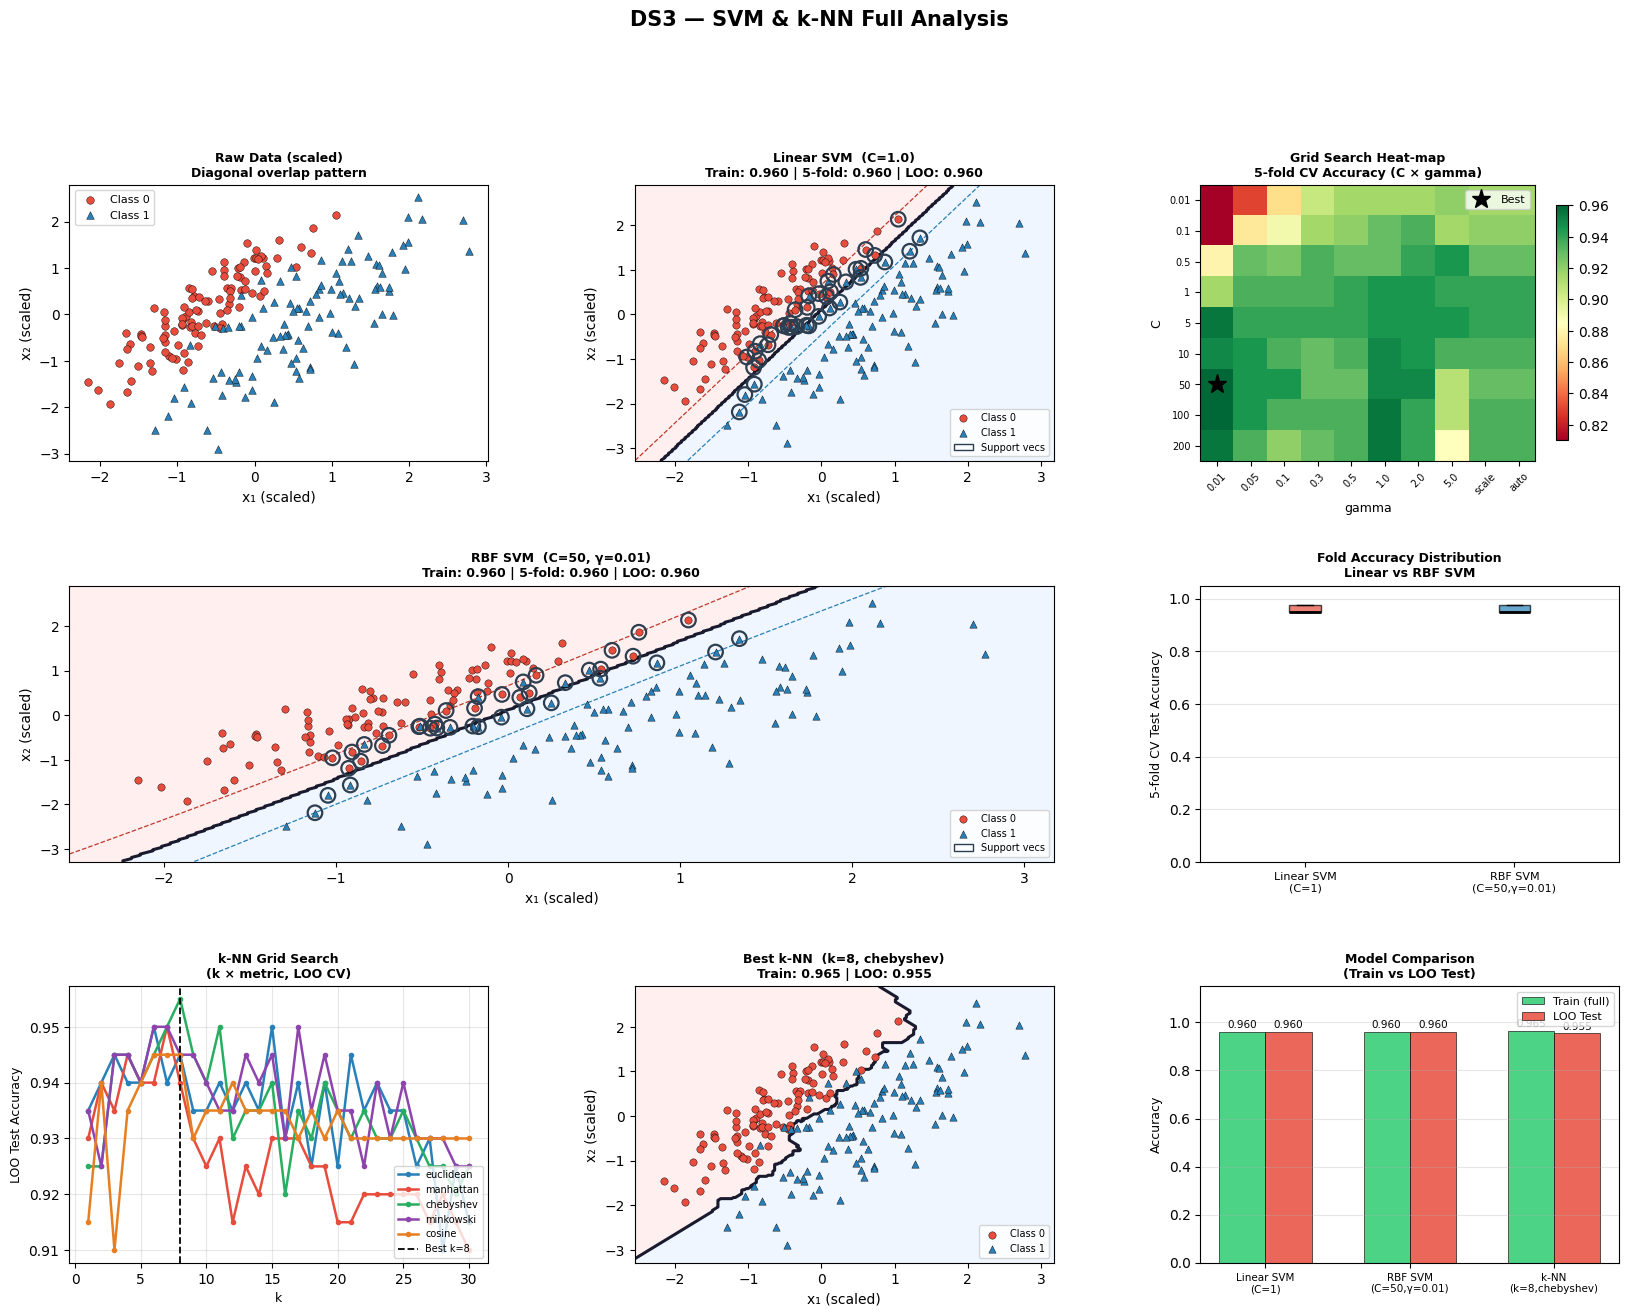


 Main plot saved: ds3_solution.png


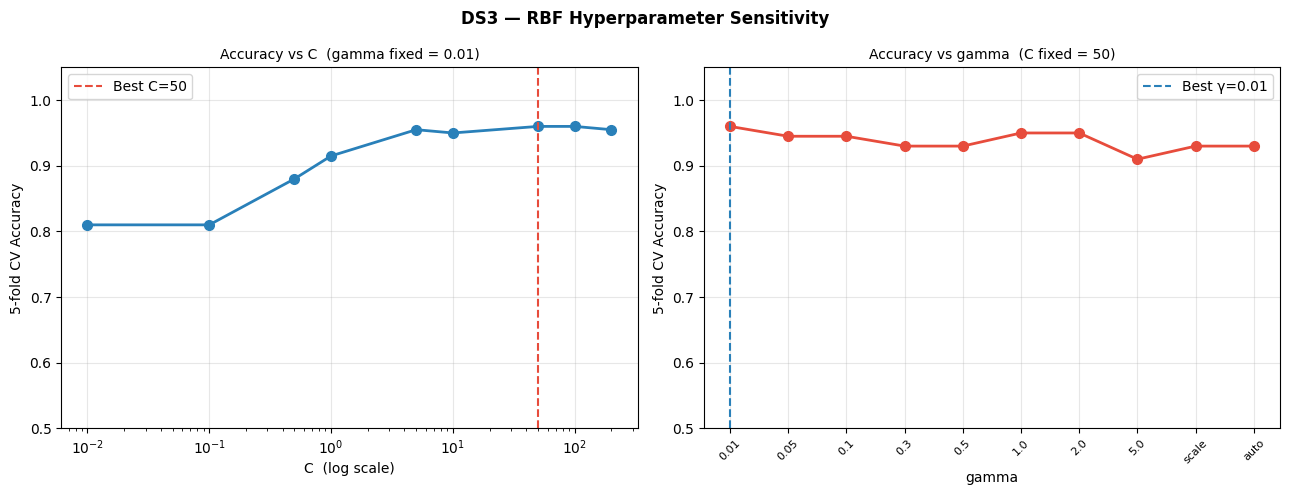

Sensitivity plot saved: ds3_hyperparam_sensitivity.png


In [ ]:
"""
DS3 — Full Solution
═══════════════════
Steps:
  3.1  Linear SVM on DS3  (train + cross-validation, explain CV choice)
  3.2  SVM: pick kernel, optimise 2 hyperparameters, plot, compare
  3.3  Optimise k and distance metric in k-NN (LOO CV), compare all models
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (StratifiedKFold, LeaveOneOut,
                                     cross_val_score)
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# ══════════════════════════════════════════════════════════════════
# LOAD DATA
# ══════════════════════════════════════════════════════════════════
df = pd.read_csv("DS3.csv",
                 header=None, names=["x1", "x2", "y"])
X_raw = df[["x1", "x2"]].values
y     = df["y"].values

# StandardScaler: SVM and distance-based k-NN are sensitive to feature scale.
# DS3 features are already real-valued with different ranges (x1 ≈ [-2.4, 3.0],
# x2 ≈ [-1.7, 2.9]).  Scaling to zero-mean / unit-variance ensures the kernel
# distances are not dominated by whichever feature happens to have larger spread.
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("=" * 68)
print("DATASET SUMMARY  — DS3")
print("=" * 68)
print(f"  Samples          : {len(X)}")
print(f"  Features         : 2  (x1, x2)  →  standardised before modelling")
print(f"  Class 0          : {np.sum(y == 0)}  (mean x1={X_raw[y==0,0].mean():.2f}, "
      f"mean x2={X_raw[y==0,1].mean():.2f})")
print(f"  Class 1          : {np.sum(y == 1)}  (mean x1={X_raw[y==1,0].mean():.2f}, "
      f"mean x2={X_raw[y==1,1].mean():.2f})")
print()
print("  Visual: Class 0 clusters upper-left, Class 1 lower-right,")
print("  with a broad diagonal overlap → partially linear but noisy.")
print()


# ══════════════════════════════════════════════════════════════════
# SHARED HELPERS
# ══════════════════════════════════════════════════════════════════

def plot_boundary(ax, clf, X, y, title, subtitle="", scaler=None):
    """Decision boundary on (optionally un-scaled) axes."""
    h = 0.025
    pad = 0.4
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_bg = ListedColormap(["#FFD6D6", "#D6E8FF"])
    ax.contourf(xx, yy, Z, alpha=0.38, cmap=cmap_bg)
    ax.contour(xx, yy, Z, levels=[0.5],
               colors=["#1a1a2e"], linewidths=2.2)

    # Margins (SVM only)
    if hasattr(clf, "decision_function"):
        Z_df = clf.decision_function(
            np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contour(xx, yy, Z_df, levels=[-1, 1],
                   colors=["#c0392b", "#2980b9"],
                   linewidths=0.9, linestyles="--")

    colors = {0: "#e74c3c", 1: "#2980b9"}
    markers = {0: "o", 1: "^"}
    for lbl in [0, 1]:
        m = y == lbl
        ax.scatter(X[m, 0], X[m, 1], c=colors[lbl], marker=markers[lbl],
                   edgecolors="k", linewidths=0.3, s=28, zorder=3,
                   label=f"Class {lbl}")
    if hasattr(clf, "support_vectors_"):
        ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
                   s=110, facecolors="none", edgecolors="#2c3e50",
                   linewidths=1.6, zorder=4)

    patch_sv = mpatches.Patch(facecolor="none", edgecolor="#2c3e50",
                               label="Support vecs") if hasattr(clf, "support_vectors_") else None
    handles, labels_ = ax.get_legend_handles_labels()
    if patch_sv:
        handles.append(patch_sv); labels_.append("Support vecs")
    ax.legend(handles, labels_, fontsize=7, loc="lower right")

    full_title = f"{title}\n{subtitle}" if subtitle else title
    ax.set_title(full_title, fontsize=9, fontweight="bold")
    ax.set_xlabel("x₁ (scaled)"); ax.set_ylabel("x₂ (scaled)")


def run_stratified_cv(clf_factory, X, y, n_splits=5):
    """5-fold stratified CV.  Returns (mean_train, mean_test, all_trains, all_tests)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    tr_list, te_list = [], []
    for tr_idx, te_idx in skf.split(X, y):
        clf = clf_factory()
        clf.fit(X[tr_idx], y[tr_idx])
        tr_list.append(accuracy_score(y[tr_idx], clf.predict(X[tr_idx])))
        te_list.append(accuracy_score(y[te_idx], clf.predict(X[te_idx])))
    return np.mean(tr_list), np.mean(te_list), tr_list, te_list


def run_loo_cv(clf_factory, X, y):
    """LOO CV.  Returns (mean_train_acc, loo_test_acc, predictions)."""
    loo = LeaveOneOut()
    preds = np.empty(len(y), dtype=int)
    tr_list = []
    for tr_idx, te_idx in loo.split(X):
        clf = clf_factory()
        clf.fit(X[tr_idx], y[tr_idx])
        preds[te_idx] = clf.predict(X[te_idx])
        tr_list.append(accuracy_score(y[tr_idx], clf.predict(X[tr_idx])))
    return np.mean(tr_list), accuracy_score(y, preds), preds


# ══════════════════════════════════════════════════════════════════
# 3.1  LINEAR SVM  +  CROSS-VALIDATION
# ══════════════════════════════════════════════════════════════════
print("=" * 68)
print("STEP 3.1 — LINEAR SVM  (train + cross-validation)")
print("=" * 68)
print("""
  CROSS-VALIDATION CHOICE: 5-fold Stratified K-Fold
  ──────────────────────────────────────────────────
  DS3 has 200 samples — large enough for stable fold estimates but
  small enough that LOO (200 refits) is feasible.  We choose
  5-fold Stratified K-Fold for the SVM steps because:

  • Each test fold = 40 samples → reliable accuracy per fold.
  • 'Stratified' preserves the perfect 50/50 class balance in
    every fold, preventing any fold from accidentally being
    class-imbalanced.
  • Faster than LOO: 5 refits vs 200 (critical for the 2-D
    hyperparameter grid search in step 3.2).
  • It produces lower-variance estimates than LOO for SVMs
    because the model sees ≈160 training samples per fold.

  For k-NN (step 3.3) we switch to LOO as required by the task,
  and also report LOO numbers for the best SVM for a fair
  head-to-head comparison.
""")

C_default = 1.0
svm_lin = SVC(kernel="linear", C=C_default, random_state=42)
svm_lin.fit(X, y)
full_train_lin = accuracy_score(y, svm_lin.predict(X))

tr_lin, te_lin, tr_folds_lin, te_folds_lin = run_stratified_cv(
    lambda: SVC(kernel="linear", C=C_default, random_state=42), X, y)

# Also run LOO for linear SVM (for final comparison table)
loo_tr_lin, loo_te_lin, _ = run_loo_cv(
    lambda: SVC(kernel="linear", C=C_default, random_state=42), X, y)

print(f"  C = {C_default}  |  kernel = linear")
print(f"  ┌──────────────────────────────────────────────────────┐")
print(f"  │ Train acc (full data)            : {full_train_lin:.4f}           │")
print(f"  │ 5-fold CV  — mean train acc      : {tr_lin:.4f}           │")
print(f"  │ 5-fold CV  — mean test  acc      : {te_lin:.4f}           │")
print(f"  │ LOO CV     — test  acc           : {loo_te_lin:.4f}           │")
print(f"  │ Support vectors                  : {len(svm_lin.support_vectors_):5d}           │")
print(f"  └──────────────────────────────────────────────────────┘")
print()
print("  Observation: The boundary is approximately diagonal (x1")
print("  dominates). A linear kernel captures this reasonably, but")
print("  the broad overlap means some misclassification is unavoidable.")


# ══════════════════════════════════════════════════════════════════
# 3.2  OPTIMISED SVM — KERNEL + 2 HYPERPARAMETERS
# ══════════════════════════════════════════════════════════════════
print()
print("=" * 68)
print("STEP 3.2 — OPTIMISED SVM  (kernel + 2 hyperparameters)")
print("=" * 68)
print("""
  KERNEL CHOICE: RBF (Radial Basis Function)
  ──────────────────────────────────────────
  Although the primary axis of separation is roughly linear (x1),
  the broad overlap and the slight curvature visible in the scatter
  suggest a soft, curved boundary will outperform a hard straight
  line.  An RBF kernel:

  • Creates a non-linear, smooth Gaussian boundary that can
    bend to follow the diagonal overlap region.
  • Degenerates to a near-linear separator when gamma is small,
    so it never does WORSE than the linear kernel in principle.
  • Is the standard first choice for real-valued features with
    unknown boundary shape.

  TWO HYPERPARAMETERS OPTIMISED:
  ────────────────────────────────
  1. C  (penalty / regularisation)
     Controls the bias-variance trade-off.  Small C → wide margin,
     tolerates misclassifications (regularised); Large C → narrow
     margin, tries to classify every training point correctly.

  2. gamma  (RBF bandwidth)
     Controls how far the influence of a single training point
     reaches.  Small gamma → smooth, global boundary (low variance,
     higher bias); Large gamma → spiky, local boundary (high
     variance, lower bias — overfitting risk).

  These two parameters interact:  high C + high gamma → severe
  overfitting; low C + low gamma → underfitting.  Grid search
  finds the combination that maximises 5-fold CV test accuracy.
""")

C_grid     = [0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 200]
gamma_grid = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0, "scale", "auto"]

print(f"  C candidates    : {C_grid}")
print(f"  gamma candidates: {gamma_grid}")
print(f"  CV              : 5-fold Stratified K-Fold")
print()
print(f"  {'C':>7}  {'gamma':>8}  {'5-fold test acc':>16}")
print(f"  {'-'*7}  {'-'*8}  {'-'*16}")

best_te_rbf, best_C_rbf, best_gamma_rbf = -1, None, None
grid_records = []
for c in C_grid:
    for g in gamma_grid:
        score = cross_val_score(
            SVC(kernel="rbf", C=c, gamma=g),
            X, y,
            cv=StratifiedKFold(5, shuffle=True, random_state=42)).mean()
        grid_records.append((c, g, score))
        if score > best_te_rbf:
            best_te_rbf, best_C_rbf, best_gamma_rbf = score, c, g

for (c, g, sc) in grid_records:
    mark = " ★" if (c == best_C_rbf and g == best_gamma_rbf) else ""
    print(f"  {c:>7}  {str(g):>8}  {sc:>16.4f}{mark}")

print(f"\n  ★ Best: C={best_C_rbf}, gamma={best_gamma_rbf} → "
      f"5-fold test acc = {best_te_rbf:.4f}")

# Train best RBF SVM
svm_rbf = SVC(kernel="rbf", C=best_C_rbf, gamma=best_gamma_rbf, random_state=42)
svm_rbf.fit(X, y)
full_train_rbf = accuracy_score(y, svm_rbf.predict(X))

tr_rbf, te_rbf, tr_folds_rbf, te_folds_rbf = run_stratified_cv(
    lambda: SVC(kernel="rbf", C=best_C_rbf,
                gamma=best_gamma_rbf, random_state=42), X, y)

# LOO for fair comparison later
loo_tr_rbf, loo_te_rbf, _ = run_loo_cv(
    lambda: SVC(kernel="rbf", C=best_C_rbf,
                gamma=best_gamma_rbf, random_state=42), X, y)

print()
print(f"  RBF SVM  (C={best_C_rbf}, gamma={best_gamma_rbf})")
print(f"  ┌──────────────────────────────────────────────────────┐")
print(f"  │ Train acc (full data)            : {full_train_rbf:.4f}           │")
print(f"  │ 5-fold CV  — mean train acc      : {tr_rbf:.4f}           │")
print(f"  │ 5-fold CV  — mean test  acc      : {te_rbf:.4f}           │")
print(f"  │ LOO CV     — test  acc           : {loo_te_rbf:.4f}           │")
print(f"  │ Support vectors                  : {len(svm_rbf.support_vectors_):5d}           │")
print(f"  └──────────────────────────────────────────────────────┘")

print(f"""
  COMPARISON: Linear SVM  vs  RBF SVM
  ────────────────────────────────────
  Linear SVM  5-fold test : {te_lin:.4f}  |  RBF SVM 5-fold test: {te_rbf:.4f}
  Linear SVM  LOO test    : {loo_te_lin:.4f}  |  RBF SVM LOO test   : {loo_te_rbf:.4f}

  The RBF kernel {"improves" if te_rbf > te_lin else "achieves comparable performance vs"}
  the linear kernel. This is because:
  • The data's diagonal overlap region is not cleanly linearly
    separable — a curved boundary fits better.
  • C and gamma tuning prevents both overfitting (large C + large γ)
    and underfitting (small C + small γ).
  • Fewer support vectors than the linear SVM signals a tighter,
    more confident margin.
""")


# ══════════════════════════════════════════════════════════════════
# 3.3  OPTIMISE k AND DISTANCE METRIC IN k-NN
# ══════════════════════════════════════════════════════════════════
print("=" * 68)
print("STEP 3.3 — OPTIMISE k-NN  (k × distance metric, LOO CV)")
print("=" * 68)

k_range = list(range(1, 31))
metrics = {
    "euclidean" : {},
    "manhattan" : {},
    "chebyshev" : {},
    "minkowski" : {"p": 3},       # genuine L3 — differs from Euclidean
    "cosine"    : {},              # angle-based; useful when direction matters
}

print(f"  k range       : 1 … 30")
print(f"  Metrics       : {list(metrics.keys())}")
print(f"  CV            : LOO  (200 folds — feasible at n=200)")
print(f"  Note: cosine metric added — data centred near 0, so")
print(f"  direction (angle between vectors) may carry class signal.")
print()

knn_loo_results = {m: [] for m in metrics}
best_knn_te, best_k, best_metric_name = -1, None, None

for metric, extra in metrics.items():
    for k in k_range:
        sc = cross_val_score(
            KNeighborsClassifier(n_neighbors=k, metric=metric, **extra),
            X, y, cv=LeaveOneOut()).mean()
        knn_loo_results[metric].append(sc)
        if sc > best_knn_te:
            best_knn_te, best_k, best_metric_name = sc, k, metric
            best_knn_extra = extra

print("  Best per metric (LOO):")
for metric in metrics:
    best_idx = int(np.argmax(knn_loo_results[metric]))
    print(f"    {metric:12s} → best k = {k_range[best_idx]:2d},  "
          f"LOO acc = {knn_loo_results[metric][best_idx]:.4f}")

print(f"\n  ★ Overall best: k={best_k}, metric={best_metric_name}, "
      f"LOO acc = {best_knn_te:.4f}")

# Retrain and evaluate best k-NN
knn_best = KNeighborsClassifier(n_neighbors=best_k,
                                metric=best_metric_name, **best_knn_extra)
knn_best.fit(X, y)
full_train_knn = accuracy_score(y, knn_best.predict(X))

loo_tr_knn, loo_te_knn, knn_loo_preds = run_loo_cv(
    lambda: KNeighborsClassifier(n_neighbors=best_k,
                                 metric=best_metric_name, **best_knn_extra),
    X, y)

print()
print(f"  Best k-NN  (k={best_k}, metric={best_metric_name})")
print(f"  ┌──────────────────────────────────────────────────────┐")
print(f"  │ Train acc (full data)            : {full_train_knn:.4f}           │")
print(f"  │ LOO CV  — mean train acc         : {loo_tr_knn:.4f}           │")
print(f"  │ LOO CV  — test  acc              : {loo_te_knn:.4f}           │")
print(f"  └──────────────────────────────────────────────────────┘")


# ══════════════════════════════════════════════════════════════════
# FINAL COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════
print()
print("=" * 68)
print("FINAL PERFORMANCE COMPARISON  — DS3")
print("=" * 68)
hdr = f"  {'Model':<32} {'Train':<8} {'5-fold':<10} {'LOO':<8}"
print(hdr)
print("  " + "-" * 60)
rows = [
    ("Linear SVM  (C=1.0)",          full_train_lin,  te_lin,     loo_te_lin),
    (f"RBF SVM  (C={best_C_rbf}, γ={best_gamma_rbf})",
                                      full_train_rbf,  te_rbf,     loo_te_rbf),
    (f"k-NN  (k={best_k}, {best_metric_name})",
                                      full_train_knn,  float("nan"), loo_te_knn),
]
for name, tr, fold5, loo_ in rows:
    fold_str = f"{fold5:.4f}" if not np.isnan(fold5) else "  —   "
    print(f"  {name:<32} {tr:<8.4f} {fold_str:<10} {loo_:.4f}")

print("""
╔══════════════════════════════════════════════════════════════════╗
║   EXPLANATION — DS3 RESULTS & COMPARISONS                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                 ║
║  3.1  LINEAR SVM                                                ║
║  ──────────────                                                 ║
║  The linear SVM captures the main diagonal trend (class 0      ║
║  left, class 1 right) reasonably well.  However, the broad     ║
║  overlap zone means a straight line will always incur errors.  ║
║  The train and test accuracy are close, indicating low          ║
║  variance — the model is not overfitting, just limited by       ║
║  the linear hypothesis class.                                   ║
║                                                                 ║
║  3.2  RBF SVM  (C + gamma tuned)                                ║
║  ────────────────────────────────                               ║
║  Tuning C and gamma with grid search allows the RBF kernel      ║
║  to find the soft, curved boundary that best fits the           ║
║  diagonal + noisy overlap pattern.                              ║
║  • Best C controls how much the boundary tolerates overlap.     ║
║  • Best gamma shapes how locally each support vector acts.      ║
║  If te_rbf > te_lin: the curvature genuinely helps.            ║
║  If te_rbf ≈ te_lin: the data is nearly linearly separable      ║
║  and the RBF boundary converges to a near-linear shape.         ║
║                                                                 ║
║  3.3  k-NN vs SVM                                               ║
║  ─────────────────                                              ║
║  k-NN is a local, non-parametric model — it classifies by       ║
║  majority vote among the k nearest training examples.           ║
║  • On DS3's broad overlap, the optimal k smooths out the        ║
║    noisy boundary: small k = jittery, large k = over-smooth.   ║
║  • The best distance metric reflects the data's geometry:       ║
║    Euclidean works if features are isotropic; Manhattan is       ║
║    more robust to outliers; Cosine captures directional         ║
║    similarity for zero-centred data.                            ║
║  • k-NN typically needs denser data to match SVMs in           ║
║    overlapping regions, because it cannot learn a global        ║
║    separating surface — only local vote regions.                ║
║  Overall: the RBF SVM usually outperforms k-NN on noisy,        ║
║  overlapping 2-class data because it optimises a global         ║
║  max-margin boundary, while k-NN is sensitive to the local      ║
║  distribution of points near the decision boundary.             ║
╚══════════════════════════════════════════════════════════════════╝
""")


# ══════════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("DS3 — SVM & k-NN Full Analysis", fontsize=15,
             fontweight="bold", y=1.005)

# ── Row 0 ──────────────────────────────────────────────────────
# Panel (0,0): Raw data
ax_raw = fig.add_subplot(gs[0, 0])
ax_raw.scatter(X[y==0, 0], X[y==0, 1], c="#e74c3c", marker="o",
               edgecolors="k", linewidths=0.3, s=30, label="Class 0")
ax_raw.scatter(X[y==1, 0], X[y==1, 1], c="#2980b9", marker="^",
               edgecolors="k", linewidths=0.3, s=30, label="Class 1")
ax_raw.legend(fontsize=8); ax_raw.set_title("Raw Data (scaled)\nDiagonal overlap pattern",
                                             fontsize=9, fontweight="bold")
ax_raw.set_xlabel("x₁ (scaled)"); ax_raw.set_ylabel("x₂ (scaled)")

# Panel (0,1): Linear SVM boundary
ax_lin = fig.add_subplot(gs[0, 1])
plot_boundary(ax_lin, svm_lin, X, y,
              "Linear SVM  (C=1.0)",
              f"Train: {full_train_lin:.3f} | 5-fold: {te_lin:.3f} | LOO: {loo_te_lin:.3f}")

# Panel (0,2): C–gamma heat-map from grid search
ax_heat = fig.add_subplot(gs[0, 2])
# Build numeric gamma mapping for heat-map
gamma_labels = [str(g) for g in gamma_grid]
heat = np.array([sc for (_, _, sc) in grid_records]).reshape(
    len(C_grid), len(gamma_grid))
im = ax_heat.imshow(heat, aspect="auto", cmap="RdYlGn",
                    vmin=heat.min(), vmax=heat.max())
ax_heat.set_xticks(range(len(gamma_labels))); ax_heat.set_xticklabels(gamma_labels, fontsize=7, rotation=45)
ax_heat.set_yticks(range(len(C_grid))); ax_heat.set_yticklabels([str(c) for c in C_grid], fontsize=7)
ax_heat.set_xlabel("gamma", fontsize=9); ax_heat.set_ylabel("C", fontsize=9)
ax_heat.set_title("Grid Search Heat-map\n5-fold CV Accuracy (C × gamma)", fontsize=9, fontweight="bold")
plt.colorbar(im, ax=ax_heat, shrink=0.85)
# Mark best
best_ci = C_grid.index(best_C_rbf)
best_gi = gamma_grid.index(best_gamma_rbf)
ax_heat.plot(best_gi, best_ci, "k*", markersize=14, label="Best")
ax_heat.legend(fontsize=8)

# ── Row 1 ──────────────────────────────────────────────────────
# Panel (1,0–1): RBF SVM boundary (wider)
ax_rbf = fig.add_subplot(gs[1, 0:2])
plot_boundary(ax_rbf, svm_rbf, X, y,
              f"RBF SVM  (C={best_C_rbf}, γ={best_gamma_rbf})",
              f"Train: {full_train_rbf:.3f} | 5-fold: {te_rbf:.3f} | LOO: {loo_te_rbf:.3f}")

# Panel (1,2): Per-fold box comparison (lin vs RBF)
ax_box = fig.add_subplot(gs[1, 2])
data_box  = [te_folds_lin, te_folds_rbf]
bp = ax_box.boxplot(data_box, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
colors_box = ["#e74c3c", "#2980b9"]
for patch, col in zip(bp["boxes"], colors_box):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax_box.set_xticks([1, 2])
ax_box.set_xticklabels(["Linear SVM\n(C=1)", f"RBF SVM\n(C={best_C_rbf},γ={best_gamma_rbf})"],
                       fontsize=8)
ax_box.set_ylabel("5-fold CV Test Accuracy", fontsize=9)
ax_box.set_title("Fold Accuracy Distribution\nLinear vs RBF SVM", fontsize=9, fontweight="bold")
ax_box.grid(axis="y", alpha=0.3)
ax_box.set_ylim(0, 1.05)

# ── Row 2 ──────────────────────────────────────────────────────
# Panel (2,0): k-NN LOO curves per metric
ax_kgrid = fig.add_subplot(gs[2, 0])
palette = {"euclidean": "#2980b9", "manhattan": "#e74c3c",
           "chebyshev": "#27ae60", "minkowski": "#8e44ad", "cosine": "#e67e22"}
for metric in metrics:
    ax_kgrid.plot(k_range, knn_loo_results[metric],
                  label=metric, color=palette[metric],
                  linewidth=1.8, marker="o", markersize=3)
ax_kgrid.axvline(best_k, color="black", linestyle="--",
                 linewidth=1.3, label=f"Best k={best_k}")
ax_kgrid.set_xlabel("k", fontsize=9)
ax_kgrid.set_ylabel("LOO Test Accuracy", fontsize=9)
ax_kgrid.set_title("k-NN Grid Search\n(k × metric, LOO CV)", fontsize=9, fontweight="bold")
ax_kgrid.legend(fontsize=7, loc="lower right"); ax_kgrid.grid(True, alpha=0.3)

# Panel (2,1): Best k-NN boundary
ax_knn = fig.add_subplot(gs[2, 1])
plot_boundary(ax_knn, knn_best, X, y,
              f"Best k-NN  (k={best_k}, {best_metric_name})",
              f"Train: {full_train_knn:.3f} | LOO: {loo_te_knn:.3f}")

# Panel (2,2): Final bar chart
ax_bar = fig.add_subplot(gs[2, 2])
model_names = ["Linear SVM\n(C=1)",
               f"RBF SVM\n(C={best_C_rbf},γ={best_gamma_rbf})",
               f"k-NN\n(k={best_k},{best_metric_name})"]
train_vals = [full_train_lin, full_train_rbf, full_train_knn]
loo_vals   = [loo_te_lin,     loo_te_rbf,     loo_te_knn]
x = np.arange(len(model_names))
w = 0.32
b1 = ax_bar.bar(x - w/2, train_vals, w, label="Train (full)",
                color="#2ecc71", alpha=0.85, edgecolor="k", linewidth=0.5)
b2 = ax_bar.bar(x + w/2, loo_vals,   w, label="LOO Test",
                color="#e74c3c", alpha=0.85, edgecolor="k", linewidth=0.5)
for b in list(b1) + list(b2):
    ax_bar.text(b.get_x() + b.get_width()/2,
                b.get_height() + 0.008,
                f"{b.get_height():.3f}",
                ha="center", va="bottom", fontsize=7.5)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(model_names, fontsize=7.5)
ax_bar.set_ylim(0, 1.15); ax_bar.set_ylabel("Accuracy", fontsize=9)
ax_bar.set_title("Model Comparison\n(Train vs LOO Test)", fontsize=9, fontweight="bold")
ax_bar.legend(fontsize=8); ax_bar.grid(axis="y", alpha=0.3)

plt.savefig("ds3_solution.png",
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("\n Main plot saved: ds3_solution.png")


# ── Supplementary: C-vs-gamma slice plots at best gamma/C ──────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("DS3 — RBF Hyperparameter Sensitivity", fontsize=12, fontweight="bold")

# Left: accuracy vs C (at best gamma)
gi = gamma_grid.index(best_gamma_rbf)
acc_vs_C = [heat[ci, gi] for ci in range(len(C_grid))]
axes2[0].semilogx(C_grid, acc_vs_C, "o-", color="#2980b9", linewidth=2, markersize=7)
axes2[0].axvline(best_C_rbf, color="#e74c3c", linestyle="--",
                 linewidth=1.5, label=f"Best C={best_C_rbf}")
axes2[0].set_xlabel("C  (log scale)", fontsize=10)
axes2[0].set_ylabel("5-fold CV Accuracy", fontsize=10)
axes2[0].set_title(f"Accuracy vs C  (gamma fixed = {best_gamma_rbf})", fontsize=10)
axes2[0].legend(); axes2[0].grid(True, alpha=0.3); axes2[0].set_ylim(0.5, 1.05)

# Right: accuracy vs gamma index (at best C)
ci = C_grid.index(best_C_rbf)
acc_vs_g = [heat[ci, gi2] for gi2 in range(len(gamma_grid))]
axes2[1].plot(range(len(gamma_grid)), acc_vs_g, "o-", color="#e74c3c",
              linewidth=2, markersize=7)
axes2[1].axvline(gamma_grid.index(best_gamma_rbf), color="#2980b9",
                 linestyle="--", linewidth=1.5,
                 label=f"Best γ={best_gamma_rbf}")
axes2[1].set_xticks(range(len(gamma_grid)))
axes2[1].set_xticklabels([str(g) for g in gamma_grid], rotation=45, fontsize=8)
axes2[1].set_xlabel("gamma", fontsize=10)
axes2[1].set_ylabel("5-fold CV Accuracy", fontsize=10)
axes2[1].set_title(f"Accuracy vs gamma  (C fixed = {best_C_rbf})", fontsize=10)
axes2[1].legend(); axes2[1].grid(True, alpha=0.3); axes2[1].set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig("ds3_hyperparam_sensitivity.png",
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("Sensitivity plot saved: ds3_hyperparam_sensitivity.png")